<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/KMEANS_OWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("factory_worker_safety_multimodal_dataset_v2.csv")

In [3]:
X = df[['PPE_Status','Body_Posture','Audio_Event','Activity_Detected','Motion_Intensity','PPE_Compliance_Score','Fusion_Risk_Score']]

In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
le_ppe = LabelEncoder()
le_body = LabelEncoder()
le_audio = LabelEncoder()
le_activity = LabelEncoder()
le_motion = LabelEncoder()

In [6]:
X['PPE_Status'] = le_ppe.fit_transform(X['PPE_Status'])
X['Body_Posture'] = le_body.fit_transform(X['Body_Posture'])
X['Audio_Event'] = le_audio.fit_transform(X['Audio_Event'])
X['Activity_Detected'] = le_activity.fit_transform(X['Activity_Detected'])
X['Motion_Intensity'] = le_motion.fit_transform(X['Motion_Intensity'])

/tmp/ipykernel_1084/3662847233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['PPE_Status'] = le_ppe.fit_transform(X['PPE_Status'])
/tmp/ipykernel_1084/3662847233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Body_Posture'] = le_body.fit_transform(X['Body_Posture'])
/tmp/ipykernel_1084/3662847233.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.cluster import KMeans

In [11]:
import matplotlib.pyplot as plt

In [12]:
sse = []

In [13]:
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(X_scaled)
    sse.append(km.inertia_)

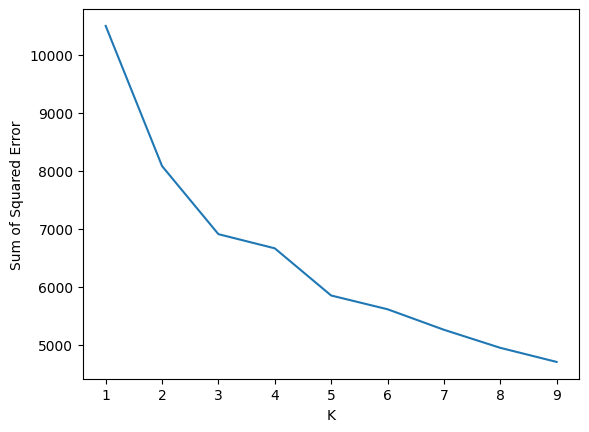

In [14]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse)
plt.show()

In [15]:
model = KMeans(n_clusters=3)

In [16]:
model.fit(X_scaled)

KMeans(n_clusters=3)

In [17]:
clusters = model.predict(X_scaled)

In [18]:
df['Cluster'] = clusters

In [19]:
print(df[['Cluster']].head())

   Cluster
0        1
1        2
2        2
3        1
4        1


In [20]:
import joblib

In [21]:
joblib.dump(model, "kmeans_model.pkl")

['kmeans_model.pkl']